In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Simulate 1000 time series samples with 20 time steps each
np.random.seed(42)
X = np.random.randn(1000, 20)  # (samples, time_steps)
y = X[:, -1] * 0.5 + X[:, -2] * -0.3 + np.random.normal(0, 0.1, 1000)  # synthetic target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [3]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 20)
(200, 20)
(800,)
(200,)


In [4]:
X_train[0]

array([ 0.11351735,  0.66213067,  1.58601682, -1.2378155 ,  2.13303337,
       -1.9520878 , -0.1517851 ,  0.58831721,  0.28099187, -0.62269952,
       -0.20812225, -0.49300093, -0.58936476,  0.8496021 ,  0.35701549,
       -0.6929096 ,  0.89959988,  0.30729952,  0.81286212,  0.62962884])

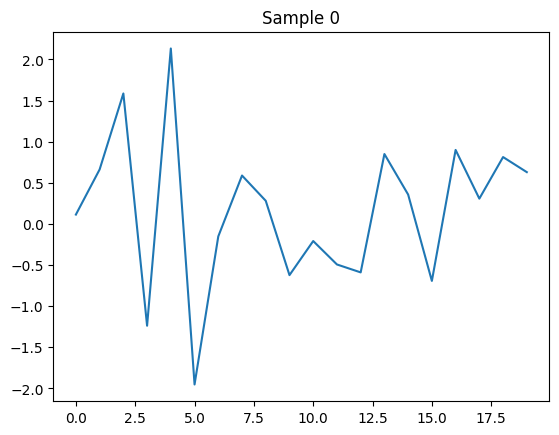

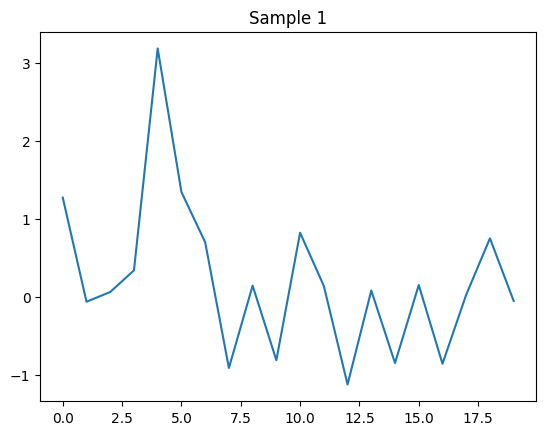

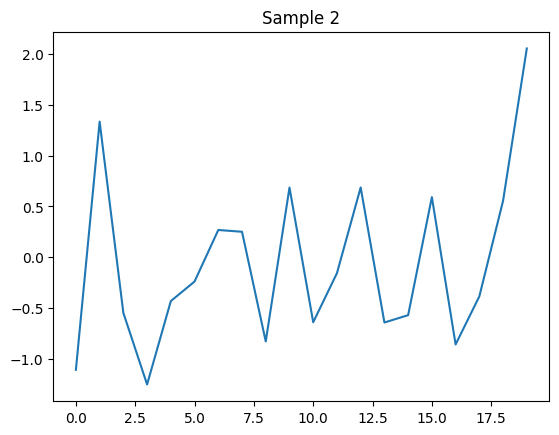

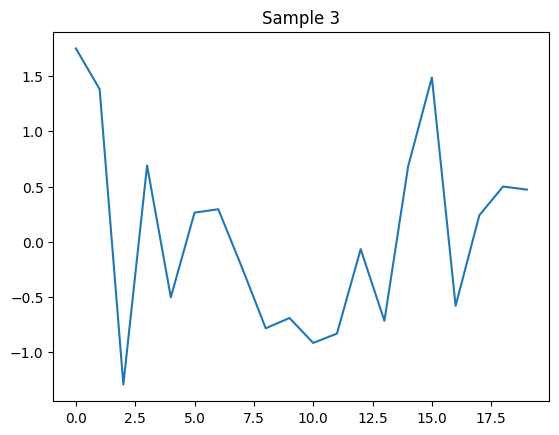

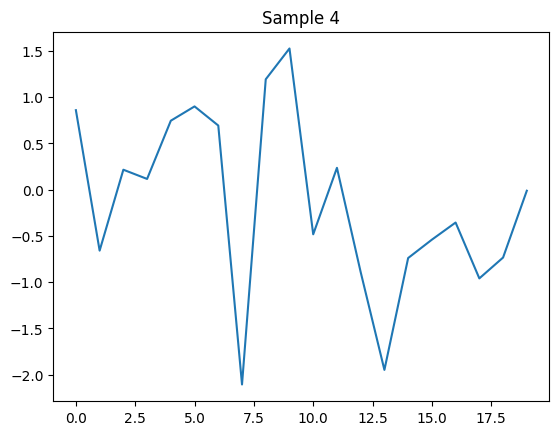

In [5]:
# Plot X_train
import matplotlib.pyplot as plt
for i in range(5):
    plt.plot(X_train[i])
    plt.title(f"Sample {i}")
    plt.show()

In [6]:
y_train[0]

np.float64(0.12325294269981263)

In [7]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [8]:
explainer_lime = LimeTabularExplainer(X_train, mode='regression', verbose=True)

In [9]:
type(explainer_lime)

lime.lime_tabular.LimeTabularExplainer

In [12]:
i = 0  # explain the first test sample
exp = explainer_lime.explain_instance(X_test[i], model.predict, num_features=10)
# exp.show_in_notebook()
print(exp.as_list())  # prints the explanation in text format

Intercept -0.08933697793743602
Prediction_local [0.28115078]
Right: 0.6403199001677108
[('19 > 0.63', 0.8896086235358526), ('18 > 0.67', -0.5054458453893262), ('-0.58 < 1 <= -0.04', -0.02809974548394306), ('-0.10 < 2 <= 0.59', 0.019741136066932178), ('9 > 0.71', -0.01756125098076831), ('5 <= -0.70', -0.01606903308494405), ('12 > 0.64', 0.01602934900476561), ('10 <= -0.71', 0.015812152939865355), ('11 > 0.74', -0.01375455863448426), ('16 <= -0.63', 0.01022693408763782)]


/Users/dquispe/Documents/repositories/ardas_platform/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dquispe/Documents/repositories/ardas_platform/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dquispe/Documents/repositories/ardas_platform/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/dquispe/Documents/repositories/ardas_platform/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dquispe/Documents/repositories/ardas_platform/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dquispe/Documents/repositories/ardas_platform/.venv/lib/python3.11/site-packages/

In [13]:
exp.save_to_file("lime_explanation.html")

In [15]:
import re

# exp.as_list() returns [("feature N", weight), ...]
lime_weights = {
    int(re.findall(r'\d+', feature)[0]): weight
    for feature, weight in exp.as_list()
}

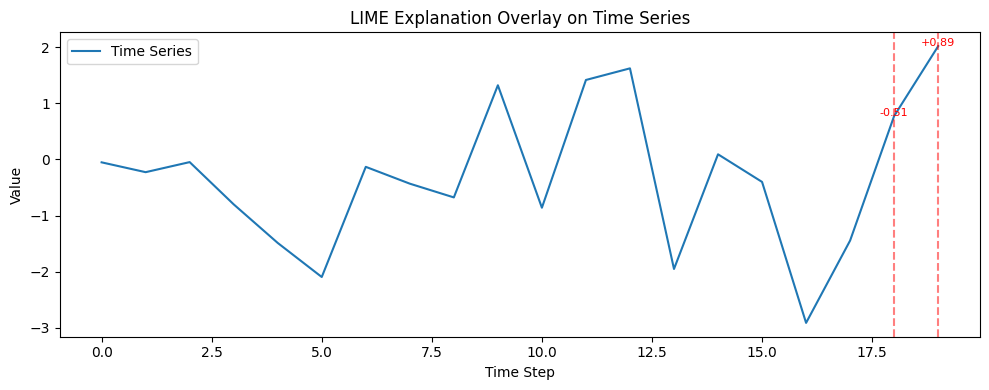

In [16]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(X_test[i]))  # time steps
y = X_test[i]  # the actual time series

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, label="Time Series")

# Highlight points with absolute weight > threshold
threshold = 0.1
for idx, weight in lime_weights.items():
    if abs(weight) > threshold:
        ax.axvline(idx, color='red', linestyle='--', alpha=0.5)
        ax.text(idx, y[idx], f'{weight:+.2f}', color='red', fontsize=8, ha='center')

ax.set_title("LIME Explanation Overlay on Time Series")
ax.set_xlabel("Time Step")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

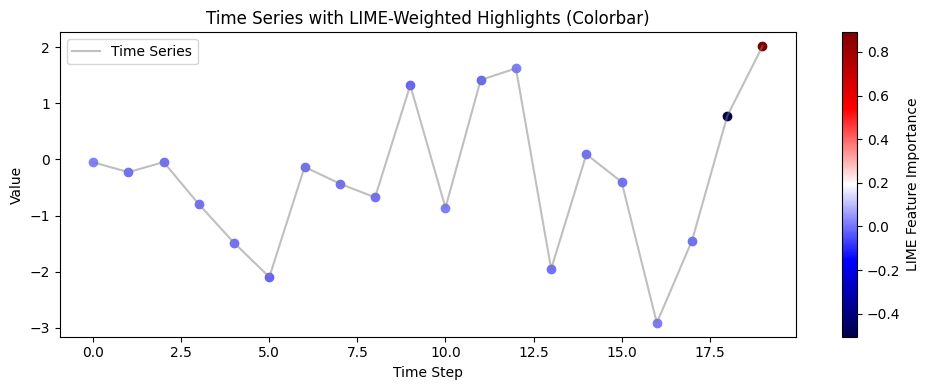

In [19]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

# Extract weights for all time steps (0 if not explained by LIME)
norm_weights = np.array([lime_weights.get(i, 0) for i in range(len(y))])

# Normalize weights for color mapping
norm = mcolors.Normalize(vmin=norm_weights.min(), vmax=norm_weights.max())
colors = cm.seismic(norm(norm_weights))

# Plot time series with colored markers
fig, ax = plt.subplots(figsize=(10, 4))
for t in range(len(y)):
    ax.plot(t, y[t], marker='o', color=colors[t])

# Plot line on top
ax.plot(x, y, color='gray', alpha=0.5, label="Time Series")

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='seismic', norm=norm)
sm.set_array([])  # Required for matplotlib >= 3.1
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("LIME Feature Importance")

ax.set_title("Time Series with LIME-Weighted Highlights (Colorbar)")
ax.set_xlabel("Time Step")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()